In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
import mne
import os
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
from tabulate import tabulate


# Resumen 

En este trabajo se analizaron señales EEG asociadas a la imaginación motora de la mano izquierda y derecha. Se extrajeron características mediante el cálculo del RMS por canal y se organizaron en un DataFrame por sujeto.

Posteriormente, se aplicaron pruebas estadísticas (Shapiro-Wilk, Levene y Mann-Whitney) para evaluar diferencias entre ambas condiciones. Los resultados no mostraron diferencias significativas, lo cual se confirmó mediante visualizaciones.

Estos resultados pueden deberse al tamaño de muestra, la variabilidad entre sujetos y el uso de una medida global como el RMS.

<p><strong>Se seleccionaron los sujetos: 1,4,12,25,39,47,59,71,82,109.<strong></p>

<p>Posteriormente se seleccionaron los runs 4, 8 y 12 correspondientes a la Task 2 del protocolo experimental, ya que estos contienen tareas de imaginería motora de mano izquierda y derecha (T1 y T2), alineadas con el objetivo del estudio.</p>

## Punto 1:Calculo de RMS 

<p>Para analizar el RMS no necesitamos todos los archivos de cada sujeto, los archivos de interés corresponden a la señal eeg y los eventos. 
<p>Sin embargo, como se hace uso del dataset de OpenNeuro, los eventos ya están dentro del .set.</p>

### Flujo de extracción de datos y cálculo de RMS para un solo archivo 

In [6]:
#Cargar el archivo
raw = mne.io.read_raw_eeglab("sujetos\sub-001_task-motion_run-4_eeg.set", preload=True)

In [ ]:
#Visualizar los eventos
events, event_id = mne.events_from_annotations(raw)
print(event_id) #identificación de T0,T1 Y T2

Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
{np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}


In [ ]:
print(raw.info) #información basica de la señal 

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
>


<p>Vemos que la frecuencia de muestreo es de 160 Hz. (160 muestras por segundo) </p>
<p>Con esta información, definimos 2 segundos después del evento, que es suficiente para capturar imaginería motora. </p>
<p> <strong>Muestras por epoca : 160 * 2 = 320 muestras<strong></p>


In [9]:
tmin = 0
tmax = 2

In [10]:
#Para crear las epocas, definimos un diccionario con los eventos de interés
eventos = {
    'left': event_id['TASK2T1'],
    'right': event_id['TASK2T2']
}

epocas = mne.Epochs(raw, events, event_id=eventos,
                    tmin=0, tmax=2, baseline=None, preload=True)

Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 321 original time points ...
0 bad epochs dropped


In [ ]:
#verificación de numero de epocas, canales y muestras 
data = epocas.get_data()
print(data.shape)

(15, 64, 321)


<p><strong>15 epocas, 64 canales y 321 muestras<strong></p>

In [35]:
print(f" Número de epocas de la mano izquierda {len(epocas['left'])}")
print(f" Número de epocas de la mano derecha {len(epocas['right'])}")

 Número de epocas de la mano izquierda 8
 Número de epocas de la mano derecha 7


In [13]:
#Separamos por epocas
data_left = epocas['left'].get_data()
data_right = epocas['right'].get_data()

In [37]:
#Función de cálculo de RMS 
def calculo_RMS(data):
    rms_epochs = np.sqrt(np.mean(data**2, axis=2))  
    rms_mean = np.mean(rms_epochs, axis=0)          
    return rms_mean

<p>Como cada canal representa la actividad eléctrica registrada en un electrodo específico del cuero cabelludo, el cálculo del RMS se realiza sobre el eje de tiempo de cada canal de forma independiente, permitiendo cuantificar la energía de la señal sin mezclar información espacial entre canales.</p>

In [ ]:
rms_left = calculo_RMS(data_left) #RMS de mano izquierda
rms_right = calculo_RMS(data_right) #RMS de mano derecha

### Flujo de extracción de datos y cálculo de RMS para los 10 sujetos 

In [ ]:
# Sujetos y runs
sujetos = [1, 4, 12, 25, 39, 47, 71, 59, 82, 109]
runs = [4, 8, 12]  #tareas 
# Lista para guardar filas
filas = []


In [ ]:
# Para guardar nombres de canales
ch_names_global = None

for s in sujetos:
    
    sujeto = f"sub-{s:03d}"
    
    rms_left_all = []
    rms_right_all = []
    
    for r in runs:
        
        archivo = os.path.join("sujetos", f"{sujeto}_task-motion_run-{r}_eeg.set")
        
        if os.path.exists(archivo):
            
            print(f"Procesando: {archivo}")
            
            # 1. Cargar señal
            raw = mne.io.read_raw_eeglab(archivo, preload=True)
            
            # Guardar nombres de canales (una sola vez)
            if ch_names_global is None:
                ch_names_global = raw.ch_names
            
            # 2. Eventos
            events, event_id = mne.events_from_annotations(raw)
            
            # 3. Épocas
            epochs = mne.Epochs(
                raw,
                events,
                event_id={
                    'TASK2T1': 2,
                    'TASK2T2': 3
                },
                tmin=0,
                tmax=2,
                baseline=None,
                preload=True
            )
            
            # 4. Separar clases
            epochs_left = epochs['TASK2T1'].get_data()
            epochs_right = epochs['TASK2T2'].get_data()
            
            # 5. RMS por época
            rms_left = np.sqrt(np.mean(epochs_left**2, axis=2))
            rms_right = np.sqrt(np.mean(epochs_right**2, axis=2))
            
            # 6. Guardar para este sujeto
            rms_left_all.append(rms_left)
            rms_right_all.append(rms_right)
        
        else:
            print(f"No existe: {archivo}")
    
    # Unir runs del mismo sujeto
    if len(rms_left_all) > 0 and len(rms_right_all) > 0:
        
        rms_left_all = np.vstack(rms_left_all)
        rms_right_all = np.vstack(rms_right_all)
        
        # Promedio por canal
        mean_left = rms_left_all.mean(axis=0)
        mean_right = rms_right_all.mean(axis=0)
        
        # Guardar en filas
        filas.append([sujeto, "izquierda"] + list(mean_left))
        filas.append([sujeto, "derecha"] + list(mean_right))


    

## Punto 2: Construcción de DataFrame 

In [ ]:
# Crear DataFrame con RMS  de todos los sujetos y canales
columnas = ["sujeto", "clase"] + ch_names_global
df = pd.DataFrame(filas, columns=columnas)

df

,sujeto,clase,Fc5,Fc3,Fc1,Fcz,Fc2,Fc4,Fc6,C5,...,P8,Po7,Po3,Poz,Po4,Po8,O1,Oz,O2,Iz
0,sub-001,izquierda,0.000046,0.000046,0.000049,0.000051,0.000048,0.000042,0.000038,0.000047,...,0.000038,0.000049,0.000050,0.000052,0.000049,0.000048,0.000051,0.000050,0.000053,0.000049
1,sub-001,derecha,0.000060,0.000059,0.000060,0.000061,0.000055,0.000047,0.000041,0.000057,...,0.000040,0.000054,0.000056,0.000059,0.000052,0.000051,0.000056,0.000055,0.000061,0.000057
2,sub-004,izquierda,0.000030,0.000027,0.000033,0.000024,0.000024,0.000023,0.000022,0.000029,...,0.000019,0.000023,0.000022,0.000026,0.000023,0.000020,0.000023,0.000023,0.000021,0.000020
3,sub-004,derecha,0.000027,0.000025,0.000042,0.000024,0.000024,0.000025,0.000024,0.000025,...,0.000020,0.000022,0.000024,0.000028,0.000023,0.000021,0.000022,0.000021,0.000021,0.000020
4,sub-012,izquierda,0.000052,0.000048,0.000047,0.000045,0.000042,0.000041,0.000038,0.000036,...,0.000029,0.000031,0.000031,0.000031,0.000031,0.000026,0.000030,0.000029,0.000030,0.000027
5,sub-012,derecha,0.000048,0.000048,0.000048,0.000047,0.000045,0.000043,0.000041,0.000036,...,0.000031,0.000030,0.000031,0.000030,0.000032,0.000027,0.000029,0.000029,0.000030,0.000026
6,sub-025,izquierda,0.000016,0.000017,0.000020,0.000014,0.000016,0.000015,0.000014,0.000015,...,0.000011,0.000013,0.000014,0.000011,0.000014,0.000013,0.000010,0.000012,0.000014,0.000010
7,sub-025,derecha,0.000017,0.000017,0.000020,0.000016,0.000017,0.000017,0.000016,0.000014,...,0.000009,0.000013,0.000015,0.000011,0.000016,0.000013,0.000010,0.000013,0.000014,0.000010
8,sub-039,izquierda,0.000118,0.000124,0.000111,0.000104,0.000100,0.000111,0.000110,0.000089,...,0.000066,0.000092,0.000075,0.000089,0.000094,0.000087,0.000073,0.000086,0.000068,0.000056
9,sub-039,derecha,0.000095,0.000106,0.000099,0.000096,0.000089,0.000097,0.000113,0.000096,...,0.000072,0.000087,0.000077,0.000077,0.000089,0.000081,0.000077,0.000087,0.000072,0.000070


## Punto 3 Pruebas estádisticas entre canales 

<p>Para realizar las pruebas estadisticas:</p>

In [8]:
# Separar clases
df_left = df[df["clase"] == "izquierda"]
df_right = df[df["clase"] == "derecha"]

# Canales
canales = df.columns[2:]

# almacenamiento de resultados
resultados = []

for canal in canales:
    datos_left = df_left[canal]
    datos_right = df_right[canal]
    
    # 1. Normalidad
    stat_s_left, p_s_left = shapiro(datos_left)
    stat_s_right, p_s_right = shapiro(datos_right)
    
    normal_left = p_s_left > 0.05
    normal_right = p_s_right > 0.05
    normal = normal_left and normal_right
    
    # 2. Homocedasticidad
    stat_lev, p_lev = levene(datos_left, datos_right)
    homoced = p_lev > 0.05
    
    # 3. Selección de prueba
    if normal and homoced:
        stat_test, p_valor = ttest_ind(datos_left, datos_right)
        test_usado = "t-test"
    else:
        stat_test, p_valor = mannwhitneyu(datos_left, datos_right, alternative='two-sided')
        test_usado = "Mann-Whitney"
    
    # Almacenar resultados
    resultados.append({
        "Canal": canal,
        "Norm. Izq (p)": f"{p_s_left:.4f}",
        "Norm. Der (p)": f"{p_s_right:.4f}",
        "Homoced. (p)": f"{p_lev:.4f}",
        "Test Usado": test_usado,
        "P-Valor Final": f"{p_valor:.4f}"
    })

# Crear DataFrame de resultados
df_resultados = pd.DataFrame(resultados)


#Visualización de resultados con tabulate
print("\n" + "="*30)
print(" RESULTADOS DEL ANÁLISIS ")
print("="*30 + "\n")

print(tabulate(df_resultados, headers='keys', tablefmt='fancy_grid', showindex=False))

# Canales significativos
# Nota: Convertimos p_valor_final a float para filtrar correctamente
df_resultados["P-Valor Final"] = pd.to_numeric(df_resultados["P-Valor Final"])
significativos = df_resultados[df_resultados["P-Valor Final"] < 0.05]

if not significativos.empty:
    print("\n" + "!"*30)
    print(" CANALES SIGNIFICATIVOS ")
    print("!"*30 + "\n")
    print(tabulate(significativos, headers='keys', tablefmt='pipe', showindex=False))
else:
    print("\nNo se encontraron canales significativos (p < 0.05).")


 RESULTADOS DEL ANÁLISIS 

╒═════════╤═════════════════╤═════════════════╤════════════════╤══════════════╤═════════════════╕
│ Canal   │   Norm. Izq (p) │   Norm. Der (p) │   Homoced. (p) │ Test Usado   │   P-Valor Final │
╞═════════╪═════════════════╪═════════════════╪════════════════╪══════════════╪═════════════════╡
│ Fc5     │          0.0116 │          0.0061 │         0.8372 │ Mann-Whitney │          1      │
├─────────┼─────────────────┼─────────────────┼────────────────┼──────────────┼─────────────────┤
│ Fc3     │          0.0139 │          0.0069 │         0.8342 │ Mann-Whitney │          0.9097 │
├─────────┼─────────────────┼─────────────────┼────────────────┼──────────────┼─────────────────┤
│ Fc1     │          0.0375 │          0.0227 │         0.9086 │ Mann-Whitney │          0.9698 │
├─────────┼─────────────────┼─────────────────┼────────────────┼──────────────┼─────────────────┤
│ Fcz     │          0.0344 │          0.0872 │         0.8558 │ Mann-Whitney │          0

<p>La prueba de normalidad de Shapiro-Wilk indicó que la mayoría de los canales no siguen una distribución normal (p < 0.05), por lo que no se cumplen los supuestos para el uso de pruebas paramétricas.
La prueba de Levene mostró homogeneidad de varianzas entre los grupos (p > 0.05).
Debido a la falta de normalidad, se empleó la prueba no paramétrica de Mann-Whitney para comparar las condiciones izquierda y derecha.
Los resultados no evidenciaron diferencias estadísticamente significativas (p < 0.05) en ninguno de los canales analizados.</p>

<p>No se encontraron diferencias estadísticamente significativas (p < 0.05) entre las condiciones izquierda y derecha en los canales analizados. Esto puede atribuirse al tamaño reducido de la muestra, la alta variabilidad inter-sujeto y al uso de una métrica global (RMS), la cual no discrimina componentes específicos de frecuencia relevantes para tareas motoras.</p>
<p>Sin embargo, se observaron tendencias diferenciales en ciertos canales, incluyendo C3 y C4, consistentes con la lateralización motora esperada.</p>

In [28]:
mejor_canal = df_resultados.sort_values("p_valor_final").iloc[0]["canal"]
print(mejor_canal)

T10


C:\Users\Karen\AppData\Local\Temp\ipykernel_17180\1128377055.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([datos_left, datos_right], labels=["Izquierda", "Derecha"])


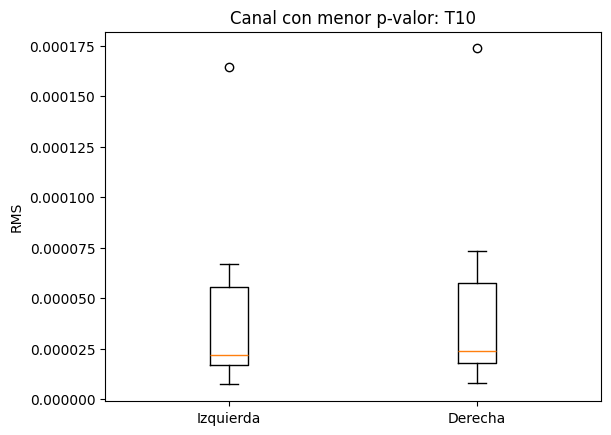

In [29]:
datos_left = df_left[mejor_canal]
datos_right = df_right[mejor_canal]

plt.boxplot([datos_left, datos_right], labels=["Izquierda", "Derecha"])
plt.title(f"Canal con menor p-valor: {mejor_canal}")
plt.ylabel("RMS")
plt.show()

<p>El diagrama de caja correspondiente al canal con menor p-valor (T10) muestra una alta superposición entre las distribuciones de las condiciones izquierda y derecha. Las medianas y rangos intercuartílicos son similares en ambos grupos, lo cual respalda los resultados obtenidos en las pruebas estadísticas, donde no se encontraron diferencias significativas. </p>

##Conclusiones